# Prediction Oil Temperature with ETTh1 dataset

### Import

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

### Read dataset

In [2]:
# Đọc dữ liệu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv("data/ETTm1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

target_col = 'OT'

data = df.values

### MSE Loss

In [3]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

### Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 69680 entries, 2016-07-01 00:00:00 to 2018-06-26 19:45:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    69680 non-null  float64
 1   HULL    69680 non-null  float64
 2   MUFL    69680 non-null  float64
 3   MULL    69680 non-null  float64
 4   LUFL    69680 non-null  float64
 5   LULL    69680 non-null  float64
 6   OT      69680 non-null  float64
dtypes: float64(7)
memory usage: 4.3 MB


In [5]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,1.492,0.426,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,1.492,0.391,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,1.492,0.426,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001


### Thông số

In [6]:
n = len(df)

train_size = int(n * 0.6)
val_size   = int(n * 0.2)
test_size = int(n * 0.2)
print(f'Train size:{train_size}')
lr = 5e-4
weight_decay = 1e-4
drop_out = 0.2

seq_len = 336
pred_len = 24

hidden_size = 256
num_layer = 3
epochs = 50

Train size:41808


### Histogram biến mục tiêu

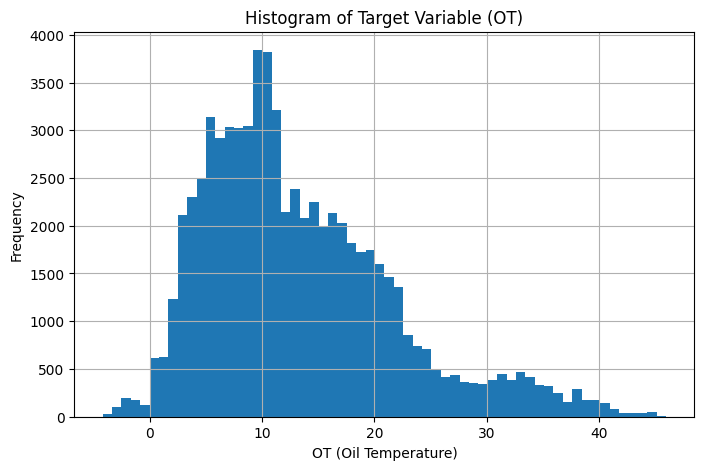

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["OT"], bins=60)
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Biểu đồ tương quan

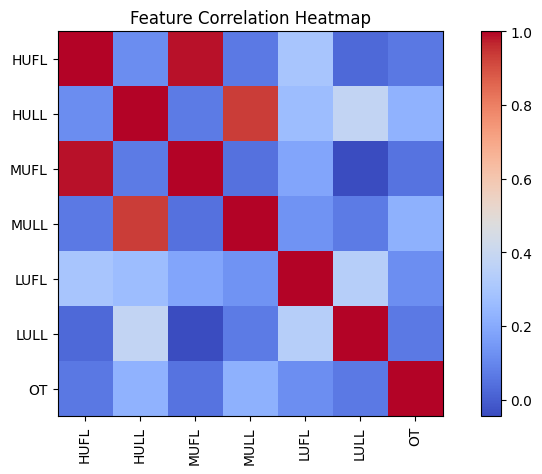

In [8]:
correlation = df.corr()
plt.figure(figsize=(10,5))
plt.imshow(correlation,cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns.tolist())), df.columns.tolist(), rotation=90)
plt.yticks(range(len(df.columns.tolist())), df.columns.tolist())

plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
# Drop cột MUFL MULL
df.drop(labels=['MUFL','MULL'],axis=1,inplace=True)

In [10]:
df.iloc[120:]

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-02 06:00:00,5.492,3.282,2.985,1.462,20.260000
2016-07-02 06:15:00,5.492,3.014,3.107,1.523,19.134001
2016-07-02 06:30:00,5.559,3.014,3.229,1.553,20.330000
2016-07-02 06:45:00,5.693,3.014,3.076,1.492,20.893000
2016-07-02 07:00:00,5.626,3.215,3.076,1.523,21.104000
...,...,...,...,...,...
2018-06-26 18:45:00,9.310,3.550,3.868,1.462,9.567000
2018-06-26 19:00:00,10.114,3.550,3.716,1.462,9.567000
2018-06-26 19:15:00,10.784,3.349,3.746,1.432,9.426000


### Data augment

In [11]:
# stl = STL(df["OT"], period=96)
# res = stl.fit()

# trend = res.trend
# seasonal = res.seasonal
# residual = res.resid

# df["trend"] = trend
# df["seasonal"] = seasonal
# df["residual"] = residual



In [12]:
df.head()

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001


### Signal plot

In [13]:
# plt.figure(figsize=(12,8))

# plt.subplot(4,1,1)
# plt.plot(df["OT"])
# plt.title("Original")

# plt.subplot(4,1,2)
# plt.plot(trend)
# plt.title("Trend")

# plt.subplot(4,1,3)
# plt.plot(seasonal)
# plt.title("Seasonal")

# plt.subplot(4,1,4)
# plt.plot(residual)
# plt.title("Residual")

# plt.tight_layout()
# plt.show()

### Chia tập train, val, test

In [14]:
train_df = df.iloc[:train_size].copy()
val_df   = df.iloc[train_size:train_size+val_size].copy()
test_df  = df.iloc[train_size+val_size:].copy()

In [15]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001


### Timer Frezee

In [16]:
df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999


In [17]:
# def fix_freeze_blocks(df, window=6):
#     df = df.copy()
#     total_fixed = 0
#     for col in df.columns:
#         diff        = df[col].diff().abs()
#         is_frozen   = (diff == 0)
#         freeze_mask = is_frozen.rolling(window).sum() >= window

#         # Mở rộng mask về đầu block (rolling nhìn về cuối)
#         # Tìm điểm bắt đầu của mỗi freeze block
#         block_end   = freeze_mask & ~freeze_mask.shift(-1).fillna(False)
#         expanded    = freeze_mask.copy()
#         for end_ts in df.index[block_end]:
#             pos = df.index.get_loc(end_ts)
#             # Lùi lại để tìm điểm bắt đầu thật sự
#             start = pos
#             while start > 0 and diff.iloc[start] == 0:
#                 start -= 1
#             expanded.iloc[start+1:pos+1] = True

#         n_fixed = expanded.sum()
#         total_fixed += n_fixed
#         df.loc[expanded, col] = np.nan

#     df = df.interpolate(method='time')
#     # Fillna đầu/cuối nếu còn sót
#     df = df.ffill().bfill()
#     print(f'Fixed {total_fixed} frozen samples across all columns')
#     return df

# df = fix_freeze_blocks(df, window=6)

In [18]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-09-07 06:30:00,10.784,4.957,2.589,0.944,18.853001
2016-09-07 06:45:00,11.655,5.827,2.650,1.066,18.923000
2016-09-07 07:00:00,10.315,5.827,2.467,1.127,19.063999
2016-09-07 07:15:00,9.042,4.488,2.437,1.066,19.275000
2016-09-07 07:30:00,8.306,4.086,2.376,1.066,19.344999
2016-09-07 07:45:00,9.712,4.890,2.406,1.097,19.486000
2016-09-07 08:00:00,9.310,5.358,2.437,1.157,19.627001
2016-09-07 08:15:00,7.703,5.090,2.498,1.249,19.837999
2016-09-07 08:30:00,8.038,5.157,2.376,1.218,20.118999


### Data Augment

In [19]:
# =============================================
# STEP 1: Fit STL chỉ trên train
# =============================================
period = 96  # ETTm1: 15-phút × 96 = 1 ngày | ETTh1: dùng 24
stl = STL(train_df["OT"], period=period)
res = stl.fit()

train_df["trend"]    = res.trend.values
train_df["seasonal"] = res.seasonal.values
train_df["residual"] = res.resid.values

# =============================================
# STEP 2: Extract pattern cố định từ train
# =============================================

# Seasonal: lấy 1 chu kỳ đại diện (mean của từng vị trí trong chu kỳ)
seasonal_pattern = np.array([
    res.seasonal[i::period].mean()
    for i in range(period)
])  # shape: (period,) — 1 ngày điển hình

def apply_seasonal(df, pattern):
    """Tile seasonal pattern theo đúng vị trí giờ trong ngày"""
    n = len(df)
    # Căn theo vị trí trong ngày thực tế để không bị lệch pha
    start_offset = (df.index[0].hour * 4 + df.index[0].minute // 15) % period
    idx = [(start_offset + i) % period for i in range(n)]
    return np.array([pattern[i] for i in idx])

# Trend: rolling mean của OT (chỉ nhìn quá khứ → không leakage)
def apply_trend(df, window=96):
    return df["OT"].rolling(window=window, min_periods=1).mean().values

# =============================================
# STEP 3: Apply cho val và test
# =============================================
for split_df in [val_df, test_df]:
    split_df["trend"]    = apply_trend(split_df, window=period)
    split_df["seasonal"] = apply_seasonal(split_df, seasonal_pattern)
    split_df["residual"] = (split_df["OT"]
                            - split_df["trend"]
                            - split_df["seasonal"]).values

In [21]:
def add_time_features(df):
    df = df.copy()
    t = df.index.hour * 4 + df.index.minute // 15
    df["time_sin"] = np.sin(2*np.pi*t/96)
    df["time_cos"] = np.cos(2*np.pi*t/96)
    return df
train_df = add_time_features(train_df)
val_df = add_time_features(val_df)
test_df = add_time_features(test_df)

In [22]:
train_df.head(10)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual,time_sin,time_cos
date,,,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.665586,7.617433,2.247981,0.000000,1.000000
2016-07-01 00:15:00,5.760,2.076,4.264,1.401,30.459999,20.662630,7.325334,2.472035,0.065403,0.997859
2016-07-01 00:30:00,5.760,1.942,4.234,1.310,30.038000,20.659676,6.820344,2.557981,0.130526,0.991445
2016-07-01 00:45:00,5.760,1.942,4.234,1.310,27.013000,20.656725,4.545272,1.811003,0.195090,0.980785
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.653778,4.590246,2.542977,0.258819,0.965926
2016-07-01 01:15:00,5.492,1.942,4.112,1.279,27.716999,20.650835,4.854280,2.211883,0.321439,0.946930
2016-07-01 01:30:00,5.358,1.875,3.929,1.340,27.646000,20.647898,4.466000,2.532101,0.382683,0.923880
2016-07-01 01:45:00,5.157,1.808,3.807,1.279,27.084000,20.644967,4.027245,2.411787,0.442289,0.896873
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.642043,4.283941,2.861016,0.500000,0.866025


### Winsorize Outliers

In [23]:
# ================================================================
# STEP 3: Winsorize outliers (clip tại IQR 1.5x)
#
# HUFL: 10.4% outliers, MUFL: 11.5%, LULL: 9.8%
# Clip thay vì remove để giữ nguyên temporal structure.
# Chỉ fit bounds trên TRAIN để tránh leakage.
# ================================================================
train_df_raw = train_df.copy()
val_df_raw   = val_df.copy()
test_df_raw  = test_df.copy()

# Compute bounds từ train
clip_bounds = {}
for col in df.columns:
    Q1  = train_df_raw[col].quantile(0.25)
    Q3  = train_df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    clip_bounds[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)

def winsorize(df, bounds):
    df = df.copy()
    for col, (lo, hi) in bounds.items():
        df[col] = df[col].clip(lo, hi)
    return df

train_df = winsorize(train_df_raw, clip_bounds)
val_df   = winsorize(val_df_raw,   clip_bounds)
test_df  = winsorize(test_df_raw,  clip_bounds)

print('Winsorize done')

Winsorize done


### Thống kê phân phối theo tập trước khi scale

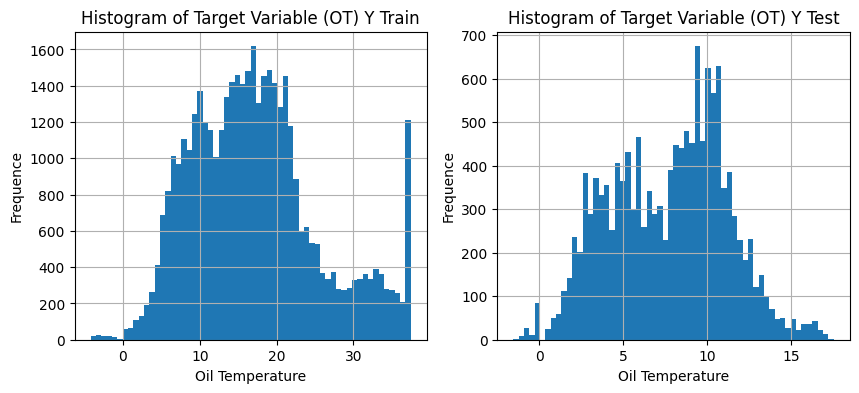

In [24]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([train_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Train')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.subplot(1,2,2)
plt.hist([test_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Test')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.show()

In [25]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

### Inverst Function

In [26]:
def inverst(x,scaler,target_index):
    return x * scaler.scale_[target_index] + scaler.mean_[target_index]
target_index = df.columns.get_loc(target_col)

In [27]:
# class TimeSeriesDataset(Dataset):
#     def __init__(self, data, seq_len, pred_len, target_index):
#         self.data = data
#         self.seq_len = seq_len
#         self.pred_len = pred_len
#         self.target_index = target_index

#     def __len__(self):
#         return len(self.data) - self.seq_len - self.pred_len + 1

#     def __getitem__(self, idx):
#         x = self.data[idx:idx+self.seq_len]
#         y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len, self.target_index]
#         return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [28]:

# # Targe Index

# print(target_index)
# train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len, target_index)
# val_dataset   = TimeSeriesDataset(val_scaled, seq_len, pred_len, target_index)
# test_dataset  = TimeSeriesDataset(test_scaled, seq_len, pred_len, target_index)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
# test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset4Seq(Dataset):
    def __init__(self, data, seq_len, pred_len):
        """
        data: mảng numpy chứa dữ liệu đã chuẩn hóa (train_scaled, val_scaled, test_scaled)
        seq_len: độ dài chuỗi quá khứ (ví dụ 96)
        pred_len: độ dài chuỗi tương lai dự đoán (ví dụ 24)
        """
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, index):
        # 1. Cắt chuỗi quá khứ (X): Lấy toàn bộ các cột (features)
        x = self.data[index : index + self.seq_len]
        
        # 2. Cắt chuỗi tương lai (Y): Lấy TOÀN BỘ các cột (Bao gồm cả Target và Future Features)
        y = self.data[index + self.seq_len : index + self.seq_len + self.pred_len]
        
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# ==========================================
# CHẠY LẠI DATALOADER VỚI DATASET MỚI
# ==========================================
batch_size = 32

train_dataset4seq = TimeSeriesDataset4Seq(train_scaled, seq_len, pred_len)
# Đã sửa 'train_dataset' thành 'train_dataset4seq'
train_loader4seq = DataLoader(train_dataset4seq, batch_size=batch_size, shuffle=True) 

val_dataset4seq = TimeSeriesDataset4Seq(val_scaled, seq_len, pred_len)
# Đã sửa 'val_dataset' thành 'val_dataset4seq'
val_loader4seq = DataLoader(val_dataset4seq, batch_size=batch_size, shuffle=False)

test_dataset4seq = TimeSeriesDataset4Seq(test_scaled, seq_len, pred_len)
# Đã sửa 'test_dataset' thành 'test_dataset4seq'
test_loader4seq = DataLoader(test_dataset4seq, batch_size=batch_size, shuffle=False)

### Thống kê phân phối dữ liệu sau khi scale

In [30]:
y_train_all = []
y_test_all = []

for i in range(len(train_dataset4seq)):
    _, y = train_dataset4seq[i]
    y_train_all.append(y.numpy())

for i in range(len(test_dataset4seq)):
    _, y = test_dataset4seq[i]
    y_test_all.append(y.numpy())

y_train_all = np.concatenate(y_train_all)
y_test_all = np.concatenate(y_test_all)

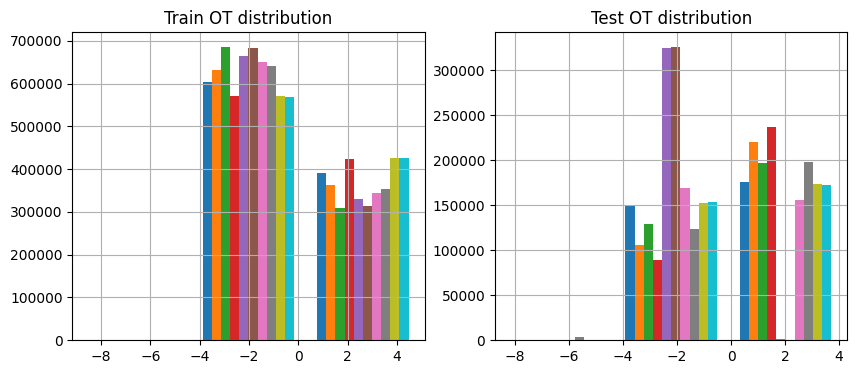

In [31]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train_all, bins=3)
plt.title("Train OT distribution")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y_test_all, bins=3)
plt.title("Test OT distribution")
plt.grid(True)
plt.show()

## Train, Test Function

In [32]:
def unified_train(model, model_type, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, target_index, scaler, patience=3, file_path='checkpoint.pth'):
    history = []
    best_val_loss = float('inf')
    train_loss = float('inf')
    best_epoch = 0
    counter = 0

    for epoch in range(epochs):
        # Chỉ dùng Teacher Forcing cho Seq2Seq, TCN thì tỷ lệ này bằng 0
        teacher_forcing_ratio = max(0.5 * (0.98 ** epoch), 0.05) if model_type == 'Seq2Seq' else 0.0
        
        model.train()
        total_train_loss = []

        for X_batch, Y_batch_full in train_loader:
            X_batch = X_batch.to(device)
            Y_batch_full = Y_batch_full.to(device)

            # 1. Bóc tách Target (Nhiệt độ)
            y_target = Y_batch_full[:, :, target_index]
            
            # 2. KHẮC PHỤC DATA LEAKAGE: Chỉ lấy 2 cột thời gian cuối cùng cho CẢ 2 mô hình
            future_features = Y_batch_full[:, :, -2:] 

            optimizer.zero_grad()

            # 3. Phân nhánh cách gọi model
            if model_type == 'Seq2Seq':
                output = model(
                    X_batch, 
                    y=y_target, 
                    future_features=future_features, 
                    teacher_forcing_ratio=teacher_forcing_ratio
                )
            elif model_type == 'TCN':
                output = model(X_batch, future_features=future_features)
            else:
                raise ValueError("model_type phải là 'Seq2Seq' hoặc 'TCN'")
            
            # 4. Tính Loss và cập nhật trọng số
            loss = criterion(output, y_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            # Inverse transform để tính toán MSE trên không gian dữ liệu gốc
            y_train_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
            y_train_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
            loss_real = mse_loss(y_train_pred, y_train_true)
            total_train_loss.append(loss_real)

        # -----------------------------
        # VALIDATION PHASE
        # -----------------------------
        model.eval()
        total_val_loss = []

        with torch.no_grad():
            for X_val_batch, Y_val_full in val_loader:
                X_val_batch = X_val_batch.to(device)
                Y_val_full = Y_val_full.to(device)
                
                y_val_target = Y_val_full[:, :, target_index]
                
                # KHẮC PHỤC DATA LEAKAGE: Chỉ lấy 2 cột thời gian cuối cùng
                val_future_features = Y_val_full[:, :, -2:] 

                # Khi Validation, tắt Teacher Forcing (truyền y=None)
                if model_type == 'Seq2Seq':
                    output = model(
                        X_val_batch, 
                        y=None, 
                        future_features=val_future_features, 
                        teacher_forcing_ratio=0.0
                    )
                else:
                    output = model(X_val_batch, future_features=val_future_features)
                
                y_val_true = inverst(y_val_target.detach().cpu().numpy(), scaler, target_index)
                y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
                loss_real_val = mse_loss(y_val_pred, y_val_true)
                total_val_loss.append(loss_real_val)
                
        total_train_loss = np.average(total_train_loss)
        total_val_loss = np.average(total_val_loss)
        scheduler_reduce.step(total_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {total_train_loss:.4f} | Val Loss: {total_val_loss:.4f} | LR: {current_lr:.6f}")
        
        # Early Stopping & Lưu Model
        if total_val_loss < best_val_loss:
            train_loss = total_train_loss
            best_val_loss = total_val_loss
            best_epoch = epoch + 1
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': total_val_loss,
                'train_loss': total_train_loss
            }, file_path)
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
                
        history.append((total_train_loss, total_val_loss))
        
    return best_epoch, best_val_loss, train_loss, history


def unified_predict(model, model_type, data_loader, device, target_index, scaler, file_path='checkpoint.pth'):
    checkpoint = torch.load(file_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    total_loss = []
    preds, trues = [] , []
    
    with torch.no_grad():
        for X_batch, Y_batch_full in data_loader: 
            X_batch = X_batch.to(device)
            Y_batch_full = Y_batch_full.to(device)
            
            y_target = Y_batch_full[:, :, target_index]
            
            # KHẮC PHỤC DATA LEAKAGE: Chỉ lấy 2 cột thời gian cuối cùng
            future_features = Y_batch_full[:, :, -2:] 
            
            # Dự đoán (Tắt Teacher Forcing)
            if model_type == 'Seq2Seq':
                output = model(
                    X_batch, 
                    y=None, 
                    future_features=future_features, 
                    teacher_forcing_ratio=0.0
                )
            else:
                output = model(X_batch, future_features=future_features)
            
            y_val_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
            y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
            
            loss = mse_loss(y_val_pred, y_val_true)
            total_loss.append(loss)
            
            preds.append(y_val_pred)
            trues.append(y_val_true)
            
    total_loss = np.average(total_loss)
    print(f'Test MSE Loss: {total_loss:.4f}')
    
    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    
    return preds, trues, total_loss

In [33]:
# import numpy as np
# import torch

# def unified_train(model, model_type, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, target_index, scaler, patience=3, file_path='checkpoint.pth'):
#     history = []
#     best_val_loss = float('inf')
#     train_loss = float('inf')
#     best_epoch = 0
#     counter = 0

#     for epoch in range(epochs):
#         teacher_forcing_ratio = max(0.5 * (0.98 ** epoch), 0.05) if model_type == 'Seq2Seq' else 0.0
#         model.train()
#         total_train_loss = []

#         for X_batch, Y_batch_full in train_loader:
#             X_batch, Y_batch_full = X_batch.to(device), Y_batch_full.to(device)
#             y_target = Y_batch_full[:, :, target_index]
            
#             # --- ĐÂY LÀ ĐOẠN ĐÃ ĐƯỢC SỬA ĐỂ TCN KHÔNG BỊ LỖI SHAPE ---
#             if model_type == 'Seq2Seq':
#                 if Y_batch_full.shape[-1] > 1:
#                     future_features = torch.cat([Y_batch_full[:, :, :target_index], Y_batch_full[:, :, target_index+1:]], dim=-1)
#                 else:
#                     future_features = None
#             elif model_type == 'TCN':
#                 future_features = Y_batch_full[:, :, -2:] # Chỉ lấy 2 cột cuối

#             optimizer.zero_grad()
#             if model_type == 'Seq2Seq':
#                 output = model(X_batch, y=y_target, future_features=future_features, teacher_forcing_ratio=teacher_forcing_ratio)
#             else:
#                 output = model(X_batch, future_features=future_features)
            
#             loss = criterion(output, y_target)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#             optimizer.step()

#             y_train_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#             y_train_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
#             total_train_loss.append(mse_loss(y_train_pred, y_train_true))

#         model.eval()
#         total_val_loss = []
#         with torch.no_grad():
#             for X_val_batch, Y_val_full in val_loader:
#                 X_val_batch, Y_val_full = X_val_batch.to(device), Y_val_full.to(device)
#                 y_val_target = Y_val_full[:, :, target_index]
                
#                 # Sửa tương tự cho Validation
#                 if model_type == 'Seq2Seq':
#                     if Y_val_full.shape[-1] > 1:
#                         val_future_features = torch.cat([Y_val_full[:, :, :target_index], Y_val_full[:, :, target_index+1:]], dim=-1)
#                     else:
#                         val_future_features = None
#                 elif model_type == 'TCN':
#                     val_future_features = Y_val_full[:, :, -2:]

#                 if model_type == 'Seq2Seq':
#                     output = model(X_val_batch, y=None, future_features=val_future_features, teacher_forcing_ratio=0.0)
#                 else:
#                     output = model(X_val_batch, future_features=val_future_features)
                
#                 y_val_true = inverst(y_val_target.detach().cpu().numpy(), scaler, target_index)
#                 y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#                 total_val_loss.append(mse_loss(y_val_pred, y_val_true))
                
#         total_train_loss = np.average(total_train_loss)
#         total_val_loss = np.average(total_val_loss)
#         scheduler_reduce.step(total_val_loss)
        
#         print(f"Epoch {epoch+1:02d} | Train Loss: {total_train_loss:.4f} | Val Loss: {total_val_loss:.4f}")
        
#         if total_val_loss < best_val_loss:
#             train_loss = total_train_loss
#             best_val_loss = total_val_loss
#             best_epoch = epoch + 1
#             torch.save({'epoch': best_epoch, 'model_state_dict': model.state_dict(), 'optimizer_state_dict': optimizer.state_dict(), 'val_loss': total_val_loss, 'train_loss': total_train_loss}, file_path)
#             counter = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 print(f"Early stopping at epoch {epoch+1}")
#                 break
#         history.append((total_train_loss, total_val_loss))
#     return best_epoch, best_val_loss, train_loss, history

# def unified_predict(model, model_type, data_loader, device, target_index, scaler, file_path='checkpoint.pth'):
#     checkpoint = torch.load(file_path, map_location=device, weights_only=False)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.eval()
    
#     total_loss, preds, trues = [], [], []
#     with torch.no_grad():
#         for X_batch, Y_batch_full in data_loader: 
#             X_batch, Y_batch_full = X_batch.to(device), Y_batch_full.to(device)
#             y_target = Y_batch_full[:, :, target_index]
            
#             if model_type == 'Seq2Seq':
#                 if Y_batch_full.shape[-1] > 1:
#                     future_features = torch.cat([Y_batch_full[:, :, :target_index], Y_batch_full[:, :, target_index+1:]], dim=-1)
#                 else:
#                     future_features = None
#             elif model_type == 'TCN':
#                 future_features = Y_batch_full[:, :, -2:]
            
#             if model_type == 'Seq2Seq':
#                 output = model(X_batch, y=None, future_features=future_features, teacher_forcing_ratio=0.0)
#             else:
#                 output = model(X_batch, future_features=future_features)
            
#             y_val_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
#             y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#             total_loss.append(mse_loss(y_val_pred, y_val_true))
#             preds.append(y_val_pred)
#             trues.append(y_val_true)
            
#     total_loss = np.average(total_loss)
#     print(f'Test MSE Loss: {total_loss:.4f}')
#     return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0), total_loss


## Seq2SeqLSTM Model

In [34]:
import torch
import torch.nn as nn
import random

# ======================
# Encoder
# ======================
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True
        )

    # def forward(self, x):
    #     outputs, (hidden, cell) = self.lstm(x)

    #     # reshape hidden
    #     num_layers = hidden.shape[0] // 2
    #     batch = x.size(0)
    #     hidden_size = hidden.size(-1)

    #     hidden = hidden.view(num_layers, 2, batch, hidden_size)
    #     cell = cell.view(num_layers, 2, batch, hidden_size)
    #     hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
    #     cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

    #     return outputs, hidden, cell
    def forward(self, x):
            # x: (batch, seq_len, input_dim)
            outputs, (hidden, cell) = self.lstm(x)

            # outputs: (batch, seq_len, hidden_size * 2) -> Do bidirectional=True
            
            # hidden ban đầu: (num_layers * 2, batch, hidden_size) = (4, batch, hidden_size)
            # Trong đó: 
            # hidden[0]: layer 1 forward,  hidden[1]: layer 1 backward
            # hidden[2]: layer 2 forward,  hidden[3]: layer 2 backward

            batch = x.size(0)
            hidden_size = hidden.size(-1)

            # 1. Tách và gộp các hướng (Forward + Backward) cho hidden
            # Chúng ta lấy forward và backward của từng lớp rồi ghép lại ở chiều cuối (dim=2)
            # Kết quả: (num_layers, batch, hidden_size * 2) = (2, batch, 256)
            hidden = torch.cat([hidden[0:hidden.size(0):2], hidden[1:hidden.size(0):2]], dim=2)
            
            # 2. Làm tương tự cho cell state
            cell = torch.cat([cell[0:cell.size(0):2], cell[1:cell.size(0):2]], dim=2)

            # Bây giờ:
            # hidden[-1] sẽ có shape (batch, 256) -> Khớp hoàn toàn với Attention yêu cầu
            return outputs, hidden, cell

# ======================
# Attention
# ======================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.scale = 1.0 / (hidden_size ** 0.5)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hidden*2)
        # encoder_outputs: (batch, seq_len, hidden*2)

        hidden = hidden.unsqueeze(1)  # (batch, 1, hidden*2)

        attn = torch.bmm(hidden, encoder_outputs.transpose(1, 2))
        attn = torch.softmax(attn * self.scale, dim=-1)

        context = torch.bmm(attn, encoder_outputs)  # (batch, 1, hidden*2)

        return context.squeeze(1)


# ======================
# Decoder
# ======================
class Decoder(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout):
        super().__init__()

        self.attn = Attention(hidden_size * 2)

        self.lstm = nn.LSTM(
            input_size=input_dim + hidden_size * 2,
            hidden_size=hidden_size * 2,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, decoder_input, hidden, cell, encoder_outputs):
        # decoder_input: (batch, 1, input_dim)

        context = self.attn(hidden[-1], encoder_outputs)

        lstm_input = torch.cat([decoder_input.squeeze(1), context], dim=1)
        lstm_input = lstm_input.unsqueeze(1)

        out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        pred = self.fc(out.squeeze(1))

        return pred, hidden, cell


# ======================
# Seq2Seq
# ======================
class Seq2SeqLSTM(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_size=128,
        num_layers=2,
        pred_len=24,
        dropout=0.2,
        target_idx=0
    ):
        super().__init__()

        self.encoder = Encoder(input_dim, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_dim, hidden_size, num_layers, dropout)

        self.pred_len = pred_len
        self.target_idx = target_idx


    def forward(self, x, y=None, future_features=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        # 1. Đưa chuỗi quá khứ qua Encoder
        encoder_outputs, hidden, cell = self.encoder(x)

        # 2. Khởi tạo đầu vào đầu tiên cho Decoder là bước thời gian (timestep) cuối cùng của quá khứ
        decoder_input = x[:, -1:, :]  # (batch, 1, input_dim)

        outputs = []

        # 3. Vòng lặp giải mã cho từng bước trong tương lai
        for t in range(self.pred_len):
            # Dự báo bước t
            pred, hidden, cell = self.decoder(
                decoder_input, hidden, cell, encoder_outputs
            )

            outputs.append(pred.unsqueeze(1)) # pred có shape (batch, 1) -> (batch, 1, 1)

            # --- Scheduled Sampling (Teacher Forcing) ---
            if self.training and y is not None:
                if random.random() < teacher_forcing_ratio:
                    # Lấy giá trị thực tế (Ground Truth)
                    next_input = y[:, t].unsqueeze(1).unsqueeze(2) # (batch, 1, 1)
                else:
                    # Lấy giá trị do mô hình vừa dự đoán
                    next_input = pred.unsqueeze(1)
            else:
                next_input = pred.unsqueeze(1)

            # --- Cập nhật Feature phụ (Covariates) cho bước t+1 ---
            if future_features is not None:
                next_covariates = future_features[:, t:t+1, :] # (batch, 1, input_dim - 1)
            else:
                # Trích xuất các covariate từ timestep cuối, bỏ cột target_idx
                next_covariates = torch.cat([x[:, -1:, :self.target_idx], x[:, -1:, self.target_idx+1:]], dim=-1)

            # --- Gộp lại thành Input hoàn chỉnh cho vòng lặp tiếp theo ---
            # Chèn target vào đúng vị trí target_idx để giữ nguyên thứ tự feature
            decoder_input = torch.cat([
                next_covariates[:, :, :self.target_idx],
                next_input, 
                next_covariates[:, :, self.target_idx:]
            ], dim=-1) # (batch, 1, input_dim)

        # 4. Gộp tất cả dự đoán lại
        outputs = torch.cat(outputs, dim=1) # (batch, pred_len, 1)

        return outputs.squeeze(-1) # (batch, pred_len)



In [39]:
import torch
import torch.nn as nn
import random

# ======================
# Encoder
# ======================
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        outputs, (hidden, cell) = self.lstm(x)
        hidden = torch.cat([hidden[0:hidden.size(0):2], hidden[1:hidden.size(0):2]], dim=2)
        cell = torch.cat([cell[0:cell.size(0):2], cell[1:cell.size(0):2]], dim=2)
        return outputs, hidden, cell

# ======================
# Attention
# ======================
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.scale = 1.0 / (hidden_size ** 0.5)

    def forward(self, hidden, encoder_outputs):
        hidden = hidden.unsqueeze(1) 
        attn = torch.bmm(hidden, encoder_outputs.transpose(1, 2))
        attn = torch.softmax(attn * self.scale, dim=-1)
        context = torch.bmm(attn, encoder_outputs)  
        return context.squeeze(1)

# ======================
# Decoder
# ======================
class Decoder(nn.Module):
    # Thêm covariate_dim=2 để biểu thị 2 cột time_sin, time_cos
    def __init__(self, input_dim, hidden_size, num_layers, dropout, covariate_dim=2):
        super().__init__()
        self.attn = Attention(hidden_size * 2)

        # KHẮC PHỤC LỖI 522 vs 515: 
        # Đầu vào của LSTM giờ sẽ là: 1 (Target) + covariate_dim (2) + context (hidden_size * 2)
        self.lstm = nn.LSTM(
            input_size = 1 + covariate_dim + hidden_size * 2,
            hidden_size = hidden_size * 2,
            num_layers = num_layers,
            dropout = dropout,
            batch_first = True
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

    def forward(self, decoder_input, hidden, cell, encoder_outputs):
        # decoder_input shape hiện tại chuẩn là: (batch, 1, 3)
        context = self.attn(hidden[-1], encoder_outputs)
        
        lstm_input = torch.cat([decoder_input.squeeze(1), context], dim=1)
        lstm_input = lstm_input.unsqueeze(1)

        out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        pred = self.fc(out.squeeze(1))

        return pred, hidden, cell

# ======================
# Seq2Seq
# ======================
class Seq2SeqLSTM(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2, pred_len=24, dropout=0.2, target_idx=0, covariate_dim=2):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_size, num_layers, dropout)
        self.decoder = Decoder(input_dim, hidden_size, num_layers, dropout, covariate_dim)

        self.pred_len = pred_len
        self.target_idx = target_idx
        self.covariate_dim = covariate_dim # Mặc định là 2 (time_sin, time_cos)

    def forward(self, x, y=None, future_features=None, teacher_forcing_ratio=0.5):
        batch_size = x.size(0)

        # 1. Đưa chuỗi quá khứ qua Encoder
        encoder_outputs, hidden, cell = self.encoder(x)

        # 2. Khởi tạo đầu vào đầu tiên cho Decoder 
        # CHỈ LẤY đúng Target và 2 cột thời gian cuối cùng của bước cuối (tránh lấy cả input_dim)
        last_target = x[:, -1:, self.target_idx:self.target_idx+1]
        last_covariates = x[:, -1:, -self.covariate_dim:]
        
        # Ghép lại thành input có 3 chiều: (batch, 1, 3)
        decoder_input = torch.cat([last_target, last_covariates], dim=-1)

        outputs = []

        # 3. Vòng lặp giải mã
        for t in range(self.pred_len):
            pred, hidden, cell = self.decoder(decoder_input, hidden, cell, encoder_outputs)
            outputs.append(pred.unsqueeze(1)) 

            # Teacher Forcing
            if self.training and y is not None:
                if random.random() < teacher_forcing_ratio:
                    next_input = y[:, t:t+1].unsqueeze(2)
                else:
                    next_input = pred.unsqueeze(1)
            else:
                next_input = pred.unsqueeze(1)

            # Cập nhật features (covariates) cho bước tiếp theo
            if future_features is not None:
                next_covariates = future_features[:, t:t+1, :]
            else:
                next_covariates = torch.zeros(batch_size, 1, self.covariate_dim, device=x.device)

            # Tạo decoder_input cho vòng lặp t+1 (Gồm 1 Target dự đoán + 2 Time_features)
            decoder_input = torch.cat([next_input, next_covariates], dim=-1)

        outputs = torch.cat(outputs, dim=1)
        return outputs.squeeze(-1)

In [40]:
print(train_scaled.shape)

(41808, 10)


In [41]:
model = Seq2SeqLSTM(
    input_dim = train_scaled.shape[1],
    hidden_size = hidden_size,
    num_layers = num_layer,
    pred_len = pred_len,
    dropout = drop_out,
    target_idx = target_index
).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)


In [42]:
# import numpy as np
# import torch

# history = []
# best_val_loss = float('inf')
# train_loss = float('inf')
# best_epoch = 0
# patience = 3
# counter = 0

# for epoch in range(epochs):
#     teacher_forcing_ratio = max(0.5 * (0.98 ** epoch), 0.05)
#     model.train()
#     total_train_loss = []

#     for X_batch, Y_batch_full in train_loader4seq:
#         X_batch = X_batch.to(device)
#         Y_batch_full = Y_batch_full.to(device)

#         # 1. Tách Target và Future Features từ Y_batch_full
#         y_target = Y_batch_full[:, :, target_index]
        
#         # Lấy tất cả các cột trừ cột target_index để làm future_features
#         if Y_batch_full.shape[-1] > 1:
#             future_features = torch.cat([
#                 Y_batch_full[:, :, :target_index], 
#                 Y_batch_full[:, :, target_index+1:]
#             ], dim=-1)
#         else:
#             future_features = None

#         optimizer.zero_grad()

#         # 2. Truyền ĐẦY ĐỦ y_target và future_features vào mô hình
#         output = model(
#             X_batch, 
#             y=y_target, 
#             future_features=future_features, 
#             teacher_forcing_ratio=teacher_forcing_ratio
#         )
        
#         # 3. Tính loss chỉ trên y_target
#         loss = criterion(output, y_target)

#         loss.backward() # Backpropagation Through Time
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient Clipping
#         optimizer.step() # Gradient Descent update

#         # 4. Tính loss thực tế mang ý nghĩa vật lý (Độ C)
#         y_train_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#         y_train_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
#         loss_real = mse_loss(y_train_pred, y_train_true)
#         total_train_loss.append(loss_real)

#     # ===== VALIDATION =====
#     model.eval()
#     total_val_loss = []

#     with torch.no_grad():
#         for X_val_batch, Y_val_full in val_loader4seq:
#             X_val_batch = X_val_batch.to(device)
#             Y_val_full = Y_val_full.to(device)
            
#             y_val_target = Y_val_full[:, :, target_index]
            
#             if Y_val_full.shape[-1] > 1:
#                 val_future_features = torch.cat([
#                     Y_val_full[:, :, :target_index], 
#                     Y_val_full[:, :, target_index+1:]
#                 ], dim=-1)
#             else:
#                 val_future_features = None

#             # QUAN TRỌNG: Không dùng Teacher Forcing (y=None), nhưng VẪN PHẢI CÓ future_features
#             output = model(
#                 X_val_batch, 
#                 y=None, 
#                 future_features=val_future_features, 
#                 teacher_forcing_ratio=0.0
#             )
            
#             y_val_true = inverst(y_val_target.detach().cpu().numpy(), scaler, target_index)
#             y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#             loss_real_val = mse_loss(y_val_pred, y_val_true)
#             total_val_loss.append(loss_real_val)
            
#     total_train_loss = np.average(total_train_loss)
#     total_val_loss = np.average(total_val_loss)
#     scheduler_reduce.step(total_val_loss)
#     current_lr = optimizer.param_groups[0]['lr']
    
#     print(
#         f"Epoch {epoch+1:02d} | "
#         f"Train Loss: {total_train_loss:.4f} | "
#         f"Val Loss: {total_val_loss:.4f} |"
#         f"LR: {current_lr:.6f}"
#     )
    
#     # ===== SAVE BEST MODEL =====
#     if total_val_loss < best_val_loss:
#         train_loss = total_train_loss
#         best_val_loss = total_val_loss
#         best_epoch = epoch + 1
#         torch.save({
#             'epoch': best_epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_loss': total_val_loss,
#             'train_loss': total_train_loss,
#             'lr': lr,
#             'drop_out': drop_out,
#             'seq_len': seq_len,
#             'pred_len': pred_len
#         }, "seq2seq_checkpoint4seq.pth")
#         counter = 0
#     else:
#         counter += 1
#         if counter >= patience:
#             print(f"Early stopping at epoch {epoch+1}")
#             break
            
#     history.append((total_train_loss, total_val_loss))

In [43]:
# Gọi hàm để TRAIN Seq2Seq
best_epoch, best_val_loss, train_loss, history = unified_train(
    model=model,
    model_type='Seq2Seq',   # Chú ý cờ này
    train_loader=train_loader4seq,
    val_loader=val_loader4seq,
    optimizer=optimizer,
    criterion=criterion,
    scheduler_reduce=scheduler_reduce,
    device=device,
    epochs=epochs,
    target_index=target_index,
    scaler=scaler,
    patience=3,
    file_path="seq2seq_checkpoint4seq.pth"
)

# Gọi hàm để PREDICT Seq2Seq
preds, trues, total_loss = unified_predict(
    model=model,
    model_type='Seq2Seq',   # Chú ý cờ này
    data_loader=test_loader4seq,
    device=device,
    target_index=target_index,
    scaler=scaler,
    file_path="seq2seq_checkpoint4seq.pth"
)


Epoch 01 | Train Loss: 2.6036 | Val Loss: 13.1182 | LR: 0.000500
Epoch 02 | Train Loss: 1.1985 | Val Loss: 5.0788 | LR: 0.000500
Epoch 03 | Train Loss: 1.1289 | Val Loss: 6.3768 | LR: 0.000500
Epoch 04 | Train Loss: 1.0905 | Val Loss: 5.4248 | LR: 0.000500
Epoch 05 | Train Loss: 1.0480 | Val Loss: 5.1682 | LR: 0.000500
Early stopping at epoch 5
Test MSE Loss: 6.6834


In [44]:
print(f'Best Epoch:{best_epoch}')
print(f'Train Loss: {train_loss}')
print(f'Val Loss: {best_val_loss}')

Best Epoch:2
Train Loss: 1.1985214352636606
Val Loss: 5.078754780975135


In [45]:
# checkpoint = torch.load("G:\\Code\\Deep Learning\\deeplearning\\OliTemperature\\seq2seq_checkpoint4seq.pth", map_location=device,weights_only=False)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()

# total_loss = []
# preds = []
# trues = []

# with torch.no_grad():
#     for X_test, Y_test_full in test_loader4seq:
#         X_test = X_test.to(device)
#         Y_test_full = Y_test_full.to(device)
        
#         # Tách Target và Future Features
#         y_test_target = Y_test_full[:, :, target_index]
        
#         if Y_test_full.shape[-1] > 1:
#             test_future_features = torch.cat([
#                 Y_test_full[:, :, :target_index], 
#                 Y_test_full[:, :, target_index+1:]
#             ], dim=-1)
#         else:
#             test_future_features = None

#         # Đưa các biến thời gian tương lai vào để mô hình có thể tạo chu kỳ
#         output = model(
#             X_test, 
#             y=None, 
#             future_features=test_future_features, 
#             teacher_forcing_ratio=0.0
#         )
        
#         y_test_true = inverst(y_test_target.detach().cpu().numpy(), scaler, target_index)
#         y_test_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
        
#         loss = mse_loss(y_test_pred, y_test_true)
#         total_loss.append(loss)
        
#         preds.append(y_test_pred)
#         trues.append(y_test_true)
        
# total_loss = np.average(total_loss)
# print(f'Test MSE Loss: {total_loss:.4f}')

# # Gộp kết quả để vẽ biểu đồ
# preds = np.concatenate(preds, axis=0)
# trues = np.concatenate(trues, axis=0)

In [46]:
print(preds.shape)
print(trues.shape)

(13577, 24)
(13577, 24)


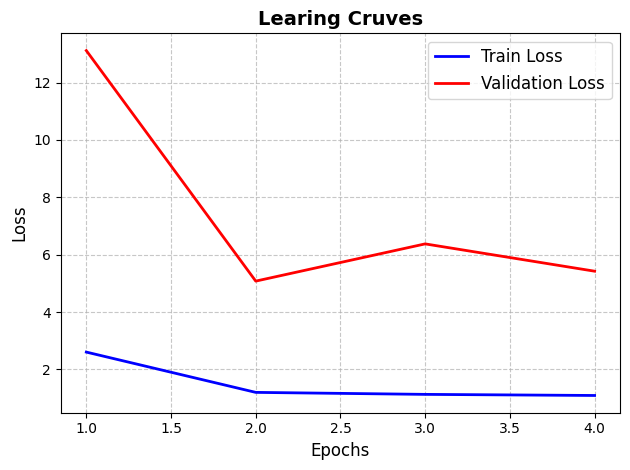

In [47]:
a,b = zip(*history)
epochss = range(1, len(a) + 1)
plt.Figure(figsize=(10,9))
plt.plot(epochss, a, 'b-', label='Train Loss', linewidth=2)
    
    # Vẽ đường Validation Loss (Màu đỏ/cam, nét liền)
plt.plot(epochss, b, 'r-', label='Validation Loss', linewidth=2)
    
    # Thêm tiêu đề và nhãn dán cho các trục
plt.title("Learing Cruves", fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
    
    # Thêm chú thích (Legend) và lưới (Grid) để dễ nhìn mốc giá trị
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
    
    # Hiển thị biểu đồ
plt.tight_layout()
plt.show()


In [48]:
print(f'Prediction: {preds[0]}')
print(f'True: {trues[0]}')
print(f'Real Loss: {total_loss}')

Prediction: [3.60390627 2.94205822 2.39074529 1.97542541 1.65066543 1.39373785
 1.18459881 1.01370235 0.87670667 0.77176564 0.69291116 0.63672152
 0.60132872 0.58583752 0.58635277 0.60154158 0.6301029  0.66927351
 0.71973179 0.77918796 0.84912511 0.92521934 1.01006977 1.10047649]
True: [3.09499966 3.44700002 3.65800011 3.51699983 3.5880003  3.09499966
 3.09499966 2.88399957 2.88399957 2.95500004 3.09499966 3.09499966
 3.02499985 3.23599993 3.51699983 3.79900038 3.5880003  3.72799992
 3.79900038 3.79900038 3.44700002 3.79900038 3.65800011 3.16600012]
Real Loss: 6.683434081075989


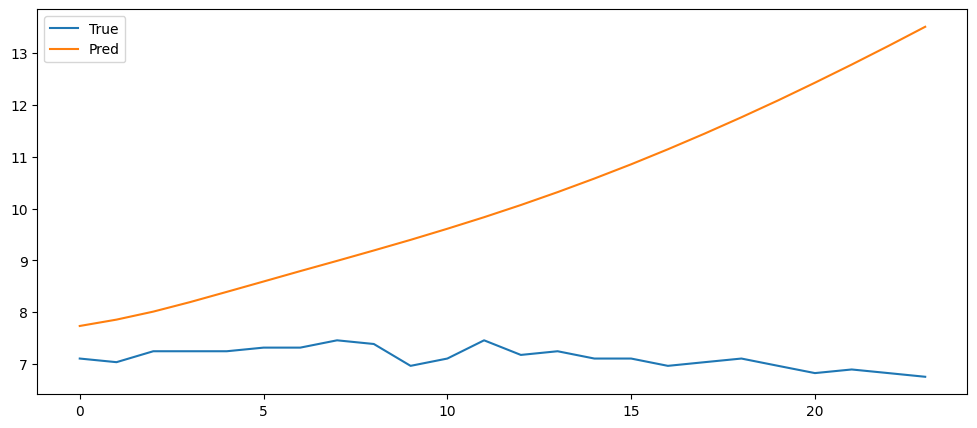

In [49]:
plt.figure(figsize=(12,5))
plt.plot(trues[10000], label="True")
plt.plot(preds[10000], label="Pred")
plt.legend()
plt.show()

### Train Fuction + Predict Function

In [50]:
# import numpy as np
# import torch

# def running_train(model, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, history, best_epoch, best_val_loss, train_loss, file,cov_dim):
#     patience = 5
#     counter = 0
    
#     for epoch in range(epochs):
#         model.train()
#         total_train_loss = []

#         # SỬ DỤNG Y_batch_full để có cả Target và Future Covariates
#         for X_batch, Y_batch_full in train_loader:
#             X_batch = X_batch.to(device)
#             Y_batch_full = Y_batch_full.to(device)

#             # 1. Bóc tách Target (Nhiệt độ)
#             y_target = Y_batch_full[:, :, target_index]
            
#             # 2. NGĂN CHẶN DATA LEAKAGE: 
#             # Chỉ lấy đúng 2 cột cuối cùng là time_sin và time_cos
#             future_features = Y_batch_full[:, :, -2:]

#             optimizer.zero_grad()

#             # 3. Truyền X_batch và future_features vào mô hình TCN (Không có y=y_target)
#             output = model(X_batch,future_features=future_features)
            
#             # 4. Tính loss trên cột nhiệt độ
#             loss = criterion(output, y_target)

#             loss.backward() # Backpropagation
#             torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradient Clipping
#             optimizer.step() # Cập nhật trọng số
            
#             # 5. Tính loss thực tế (Độ C) để dễ theo dõi
#             y_train_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#             y_train_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
#             loss_real = mse_loss(y_train_pred, y_train_true)
#             total_train_loss.append(loss_real)

#         # ===== VALIDATION =====
#         model.eval()
#         total_val_loss = []

#         with torch.no_grad():
#             for X_val_batch, Y_val_full in val_loader:
#                 X_val_batch = X_val_batch.to(device)
#                 Y_val_full = Y_val_full.to(device)
                
#                 y_val_target = Y_val_full[:, :, target_index]
                
#                 # Tương tự như tập Train: Chỉ lấy 2 cột thời gian cuối cùng
#                 val_future_features = Y_val_full[:, :, -2:]

#                 # Dự đoán trên tập Val
#                 output = model(X_val_batch, future_features=val_future_features)
                
#                 y_val_true = inverst(y_val_target.detach().cpu().numpy(), scaler, target_index)
#                 y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
#                 loss_real_val = mse_loss(y_val_pred, y_val_true)
#                 total_val_loss.append(loss_real_val)
                
#         total_train_loss = np.average(total_train_loss)
#         total_val_loss = np.average(total_val_loss)
#         scheduler_reduce.step(total_val_loss)
#         current_lr = optimizer.param_groups[0]['lr']
        
#         print(
#             f"Epoch {epoch+1:02d} | "
#             f"Train Loss: {total_train_loss:.4f} | "
#             f"Val Loss: {total_val_loss:.4f} | "
#             f"LR: {current_lr:.6f}"
#         )
        
#         # ===== SAVE BEST MODEL =====
#         if total_val_loss < best_val_loss:
#             train_loss = total_train_loss
#             best_val_loss = total_val_loss
#             best_epoch = epoch + 1
#             torch.save({
#                 'epoch': best_epoch,
#                 'model_state_dict': model.state_dict(),
#                 'optimizer_state_dict': optimizer.state_dict(),
#                 'val_loss': total_val_loss,
#                 'train_loss': total_train_loss,
#                 'lr': lr,
#                 'drop_out': drop_out,
#                 'seq_len': seq_len,
#                 'pred_len': pred_len
#             }, file)
#             counter = 0
#         else:
#             counter += 1
#             if counter >= patience:
#                 print("Early stopping")
#                 break
                
#         history.append((total_train_loss, total_val_loss))
        
#     return best_epoch, best_val_loss, train_loss, history

In [51]:
# def predict_running(model, data_loader, file):
#     # Load trọng số tốt nhất đã lưu
#     checkpoint = torch.load(file, map_location=device, weights_only=False)
#     model.load_state_dict(checkpoint['model_state_dict'])
#     model.eval()
    
#     total_loss = []
#     preds, trues = [], []
    
#     with torch.no_grad():
#         for X_batch, Y_batch_full in data_loader: 
#             X_batch = X_batch.to(device)
#             Y_batch_full = Y_batch_full.to(device)
            
#             # 1. Bóc tách Target (Nhiệt độ)
#             y_target = Y_batch_full[:, :, target_index]
            
#             # 2. NGĂN CHẶN DATA LEAKAGE: Chỉ lấy 2 cột thời gian (time_sin, time_cos)
#             future_features = Y_batch_full[:, :, -2:]
            
#             # 3. Truyền X_batch và future_features vào mô hình
#             output = model(X_batch,future_features=future_features)
            
#             # 4. Đưa y_target và output vào hàm giải chuẩn hóa
#             y_val_true = inverst(y_target.detach().cpu().numpy(), scaler, target_index)
#             y_val_pred = inverst(output.detach().cpu().numpy(), scaler, target_index)
            
#             loss = mse_loss(y_val_pred, y_val_true)
#             total_loss.append(loss)
            
#             preds.append(y_val_pred)
#             trues.append(y_val_true)
            
#     total_loss = np.average(total_loss)
#     print(f'Test MSE Loss: {total_loss:.4f}')
    
#     # Gộp toàn bộ các batch lại thành 1 mảng numpy lớn để vẽ biểu đồ
#     preds = np.concatenate(preds, axis=0)
#     trues = np.concatenate(trues, axis=0)
    
#     # In ra thử 1 chuỗi 24 giờ đầu tiên để kiểm tra trực quan
#     print(f'Trues: {trues[0]}')
#     print(f'Predict: {preds[0]}')
    
#     return preds, trues, total_loss

## TCN Bilateral Model

In [52]:
# class TemporalBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
#         super().__init__()

#         padding = (kernel_size - 1) * dilation

#         self.conv1 = nn.Conv1d(
#             in_channels, out_channels,
#             kernel_size,
#             padding=padding,
#             dilation=dilation
#         )

#         self.conv2 = nn.Conv1d(
#             out_channels, out_channels,
#             kernel_size,
#             padding=padding,
#             dilation=dilation
#         )

#         self.relu = nn.ReLU()
#         self.dropout = nn.Dropout(dropout)

#         self.downsample = nn.Conv1d(in_channels, out_channels, 1) \
#             if in_channels != out_channels else None

#     def forward(self, x):
#         # x: (batch, channels, seq_len)

#         out = self.conv1(x)
#         out = out[:, :, :x.size(2)]  # causal cut
#         out = self.relu(out)
#         out = self.dropout(out)

#         out = self.conv2(out)
#         out = out[:, :, :x.size(2)]
#         out = self.relu(out)
#         out = self.dropout(out)

#         res = x if self.downsample is None else self.downsample(x)

#         return self.relu(out + res)
# class TCN(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         num_channels,
#         kernel_size=3,
#         dropout=0.2,
#         horizon=24
#     ):
#         super().__init__()

#         layers = []
#         num_levels = len(num_channels)

#         for i in range(num_levels):
#             dilation = 2 ** i

#             in_channels = input_dim if i == 0 else num_channels[i-1]
#             out_channels = num_channels[i]

#             layers.append(
#                 TemporalBlock(
#                     in_channels,
#                     out_channels,
#                     kernel_size,
#                     dilation,
#                     dropout
#                 )
#             )

#         self.network = nn.Sequential(*layers)

#         self.fc = nn.Linear(num_channels[-1], horizon)

#     def forward(self, x):
#         # x: (batch, seq_len, input_dim)

#         x = x.permute(0, 2, 1)  # -> (batch, input_dim, seq_len)

#         y = self.network(x)

#         # lấy timestep cuối
#         y = y[:, :, -1]

#         out = self.fc(y)

#         return out

In [53]:
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm

# ======================
# Temporal Block (WaveNet Gated Style)
# ======================
class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        
        # Cổng Lọc (Filter) và Cổng Khóa (Gate) đặc trưng của WaveNet
        self.conv_filter = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation))
        self.conv_gate   = weight_norm(nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation))
        
        self.dropout = nn.Dropout(dropout)
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None

    def forward(self, x):
        # Mạch Lọc (Tanh)
        out_f = self.conv_filter(x)
        out_f = out_f[:, :, :x.size(2)]  # Causal cut
        out_f = torch.tanh(out_f)
        
        # Mạch Điều Khiển (Sigmoid)
        out_g = self.conv_gate(x)
        out_g = out_g[:, :, :x.size(2)]  # Causal cut
        out_g = torch.sigmoid(out_g)
        
        # Nhân hai mạch lại với nhau (Gated Activation)
        out = out_f * out_g
        out = self.dropout(out)
        
        res = x if self.downsample is None else self.downsample(x)
        return out + res  # Pre-activation (Không chạy activation cuối giúp gradient không bị triệt tiêu)

# ======================
# Mô hình TCN (Với Delta Prediction & Step Decoder)
# ======================
class TCN(nn.Module):
    def __init__(
        self,
        input_dim,
        num_channels,
        target_index,          # THÊM MỚI: Truyền index của cột nhiệt độ OT
        kernel_size=3,
        dropout=0.2,
        horizon=24,
        covariate_dim=2        # Để là 2 vì chúng ta chỉ dùng time_sin và time_cos
    ):
        super().__init__()
        self.horizon = horizon
        self.target_index = target_index
        
        # 1. Xây dựng mạng TCN trích xuất đặc trưng quá khứ
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation = 2 ** i
            in_channels = input_dim if i == 0 else num_channels[i-1]
            out_channels = num_channels[i]
            layers.append(TemporalBlock(in_channels, out_channels, kernel_size, dilation, dropout))
            
        self.network = nn.Sequential(*layers)
        
        # 2. Mạng nhúng đặc trưng thời gian (Time Embedding)
        self.covariate_encoder = nn.Sequential(
            nn.Linear(covariate_dim, 16),
            nn.ReLU()
        )
        
        # 3. Mạng giải mã dự báo bước tiến (Dự báo Delta)
        # Kết hợp TCN Context + Biến Tương lai -> ra 1 giá trị của 1 giờ
        self.decoder = nn.Sequential(
            nn.Linear(num_channels[-1] + 16, 64),
            nn.ReLU(),
            nn.Linear(64, 1) 
        )

    def forward(self, x, future_features=None):
        # x: (batch, seq_len, input_dim)
        # future_features: (batch, horizon, covariate_dim)
        
        # A. TRÍCH XUẤT NHIỆT ĐỘ CỦA GIỜ HIỆN TẠI ĐỂ LÀM MỐC
        last_known_val = x[:, -1, self.target_index].unsqueeze(-1) # Shape: (batch, 1)
        
        # B. TÌM NGỮ CẢNH TỪ QUÁ KHỨ BẰNG TCN
        x_tcn = x.permute(0, 2, 1)  # -> (batch, input_dim, seq_len)
        tcn_out = self.network(x_tcn)
        tcn_context = tcn_out[:, :, -1]  # Lấy vector thời điểm cuối cùng: (batch, num_channels[-1])
        
        # C. GIẢI MÃ TỪNG BƯỚC THỜI GIAN
        preds = []
        for t in range(self.horizon):
            if future_features is not None:
                # Trích đúng biến thời gian của giờ thứ 't'
                cov_t = future_features[:, t, :] # (batch, covariate_dim)
                cov_emb = self.covariate_encoder(cov_t) # (batch, 16)
            else:
                cov_emb = torch.zeros(x.size(0), 16, device=x.device)
                
            # Ghép TCN context (cố định) + Time context (biến đổi theo giờ)
            step_input = torch.cat([tcn_context, cov_emb], dim=1)
            
            # MÔ HÌNH DỰ BÁO "SỰ BIẾN ĐỘNG" (DELTA)
            delta = self.decoder(step_input) # (batch, 1)
            
            # Delta Prediction: Dự báo_mới = Gốc_hiện_tại + Độ_biến_động
            pred_t = last_known_val + delta 
            
            preds.append(pred_t)
            
        # Gộp tất cả 24 giờ lại
        out = torch.cat(preds, dim=1) # (batch, horizon)
        return out


In [54]:
# Khởi tạo mô hình TCN MỚI
TCN_model = TCN(
    input_dim=train_scaled.shape[1],
    num_channels=[64, 128, 128, 256, 256, 256, 256], 
    target_index=target_index,   # THÊM DÒNG NÀY VÀO 
    kernel_size=3,
    dropout=0.2,
    horizon=pred_len,
    covariate_dim=2 
).to(device)

# 3. Đổi hàm Loss
TCN_criterion = nn.HuberLoss(delta=1.0) # NÂNG CẤP: Dùng HuberLoss để bắt đỉnh/đáy tốt hơn MSELoss
# TCN_criterion = nn.MSELoss() 

# 4. Giữ nguyên Optimizer, Scheduler và các biến theo dõi
TCN_optimizer = torch.optim.AdamW(TCN_model.parameters(), lr=1e-3)

TCN_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    TCN_optimizer,
    mode='min',
    patience=3,
    factor=0.5
)

TCN_history = []
TCN_best_epoch = 0
TCN_best_val_loss = float('inf')
TCN_best_train_loss = float('inf')

g:\Lap trinh\Python\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [55]:
# # Gọi hàm huấn luyện cho TCN với DataLoader chứa future features
# TCN_best_epoch, TCN_best_val_loss, TCN_best_train_loss, TCN_history = running_train(
#     model=TCN_model,
#     train_loader=train_loader4seq,  # CẬP NHẬT: Dùng DataLoader 3D mới tạo
#     val_loader=val_loader4seq,      # CẬP NHẬT: Dùng DataLoader 3D mới tạo
#     optimizer=TCN_optimizer, 
#     criterion=TCN_criterion, 
#     scheduler_reduce=TCN_scheduler,
#     device=device,
#     epochs=epochs,
#     history=TCN_history, 
#     best_epoch=TCN_best_epoch, 
#     best_val_loss=TCN_best_val_loss, 
#     train_loss=TCN_best_train_loss,
#     cov_dim = 2,  # NÂNG CẤP: Truyền số lượng biến phụ vào hàm huấn luyện
#     file='TCN_checkpoint.pth',
#     patience=3
# )

In [56]:
# Gọi hàm để TRAIN TCN
TCN_best_epoch, TCN_best_val_loss, TCN_train_loss, TCN_history = unified_train(
    model=TCN_model,
    model_type='TCN',       # Đổi thành 'TCN' (tự động không truyền y)
    train_loader=train_loader4seq,
    val_loader=val_loader4seq,
    optimizer=TCN_optimizer,
    criterion=TCN_criterion,
    scheduler_reduce=TCN_scheduler,
    device=device,
    epochs=epochs,
    target_index=target_index,
    scaler=scaler,
    patience=3,
    file_path="TCN_checkpoint.pth"
)

# Gọi hàm để PREDICT TCN
TCN_preds, TCN_trues, TCN_total_loss = unified_predict(
    model=TCN_model,
    model_type='TCN',       # Đổi thành 'TCN'
    data_loader=test_loader4seq,
    device=device,
    target_index=target_index,
    scaler=scaler,
    file_path="TCN_checkpoint.pth"
)


Epoch 01 | Train Loss: 1.1084 | Val Loss: 3.0146 | LR: 0.001000
Epoch 02 | Train Loss: 0.7856 | Val Loss: 4.2192 | LR: 0.001000
Epoch 03 | Train Loss: 0.6689 | Val Loss: 4.2383 | LR: 0.001000
Epoch 04 | Train Loss: 0.6028 | Val Loss: 3.6223 | LR: 0.001000
Early stopping at epoch 4
Test MSE Loss: 3.1778


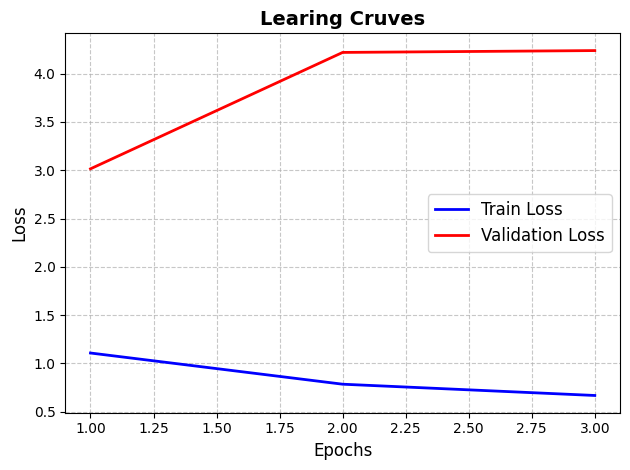

In [57]:
a,b = zip(*TCN_history)
epochss = range(1, len(a) + 1)
plt.Figure(figsize=(10,9))
plt.plot(epochss, a, 'b-', label='Train Loss', linewidth=2)
    
    # Vẽ đường Validation Loss (Màu đỏ/cam, nét liền)
plt.plot(epochss, b, 'r-', label='Validation Loss', linewidth=2)
    
    # Thêm tiêu đề và nhãn dán cho các trục
plt.title("Learing Cruves", fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
    
    # Thêm chú thích (Legend) và lưới (Grid) để dễ nhìn mốc giá trị
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
    
    # Hiển thị biểu đồ
plt.tight_layout()
plt.show()


In [58]:
print(f'TCN Best Epoch: {TCN_best_epoch}')
print(f'TCN Train Loss: {TCN_best_train_loss}')
print(f'TCN Val Loss: {TCN_best_val_loss}')

TCN Best Epoch: 1
TCN Train Loss: inf
TCN Val Loss: 3.014585503537487


In [59]:
# TCN_preds,TCN_trues,TCN_total_loss = predict_running(TCN_model,test_loader4seq,'G:\\Code\\Deep Learning\\deeplearning\\OliTemperature\\TCN_checkpoint.pth')

In [60]:
def plot_function (preds,trues,total_loss,idx,criterion):
  MSE_Loss = criterion(torch.tensor(preds[idx]),torch.tensor(trues[idx]))
  print(f'Total Loss: {total_loss}')
  print(f'Sample {idx} Loss: {MSE_Loss}')
  plt.figure(figsize=(12,5))
  plt.plot(trues[idx], label="True")
  plt.plot(preds[idx], label="Pred")
  plt.title('Predict Plot')
  plt.legend()
  plt.show()

Total Loss: 3.1777932674226452
Sample 10 Loss: 0.8075346581183718


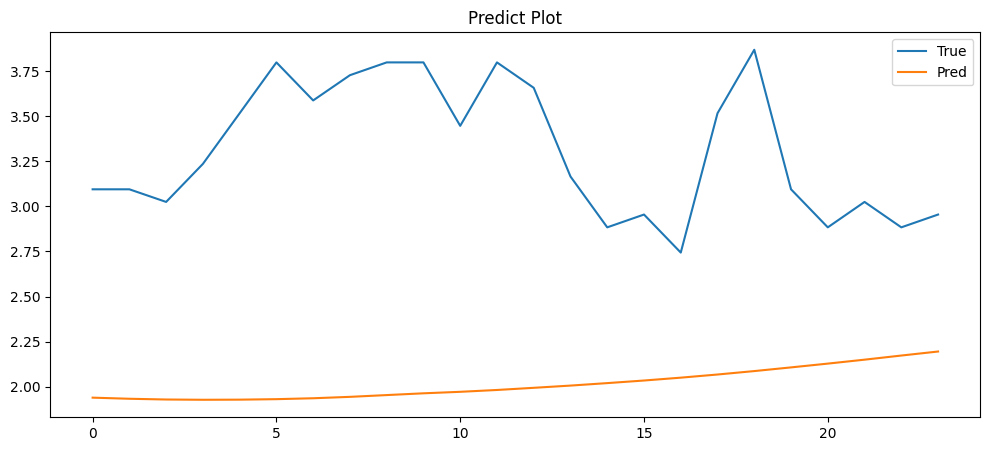

In [61]:
plot_function(TCN_preds,TCN_trues,TCN_total_loss,10,TCN_criterion)

In [62]:
def count_parameters(model):
    # Đếm tổng tất cả các tham số có yêu cầu tính gradient (requires_grad = True)
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Gọi hàm cho cả 2 mô hình (nhớ đổi tên biến model cho đúng với code của bạn)
print(f"Số tham số của Seq2Seq LSTM: {count_parameters(model):,}") 
print(f"Số tham số của TCN: {count_parameters(TCN_model):,}")

Số tham số của Seq2Seq LSTM: 10,078,465
Số tham số của TCN: 1,592,561
